In [1085]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

pd.options.mode.chained_assignment = None
data = pd.read_csv('swiss_job_offers.csv')

data = data.drop('MaternityLeaveWeeks', axis=1)
data = data.drop('PaternityLeaveWeeks', axis=1)
data = data.drop('CitySize', axis=1)
data = data.drop('Perks', axis=1)
data = data.drop('MinYearsExperience', axis=1)
data['Languages'] = data['Languages'].fillna('unknown')



#data[data.isna().any(axis=1)]
data

,Diploma,Role,Contract,Industry,Canton,CompanySize,Languages,Holidays,WorkloadPercent,SalaryCHF
0,PhD,Manager,Permanent,Education,ZH,Small (50-200),"English, German",25,100,314500
1,Bachelor,Senior,Permanent,Manufacturing,SO,Large (1000+),"French, German",25,100,143600
2,Bachelor,Mid-level,Permanent,Manufacturing,SO,Medium (200-1000),"English, German",25,100,84300
3,Bachelor,Junior,1 year,Healthcare,BE,Small (50-200),"English, German",25,90,45300
4,PhD,Mid-level,Permanent,Finance,FR,Medium (200-1000),"French, German",26,90,130200
...,...,...,...,...,...,...,...,...,...,...
495,Master,Intern,6 months,Hospitality,SO,Startup (<50),"French, English, German",28,60,25000
496,Apprenticeship,Junior,Permanent,Finance,ZH,Medium (200-1000),"French, German",25,80,67600
497,Bachelor,Senior,Permanent,Manufacturing,TG,Large (1000+),German,24,80,122200
498,Bachelor,Mid-level,2 years,Consulting,ZH,Medium (200-1000),German,28,90,103000


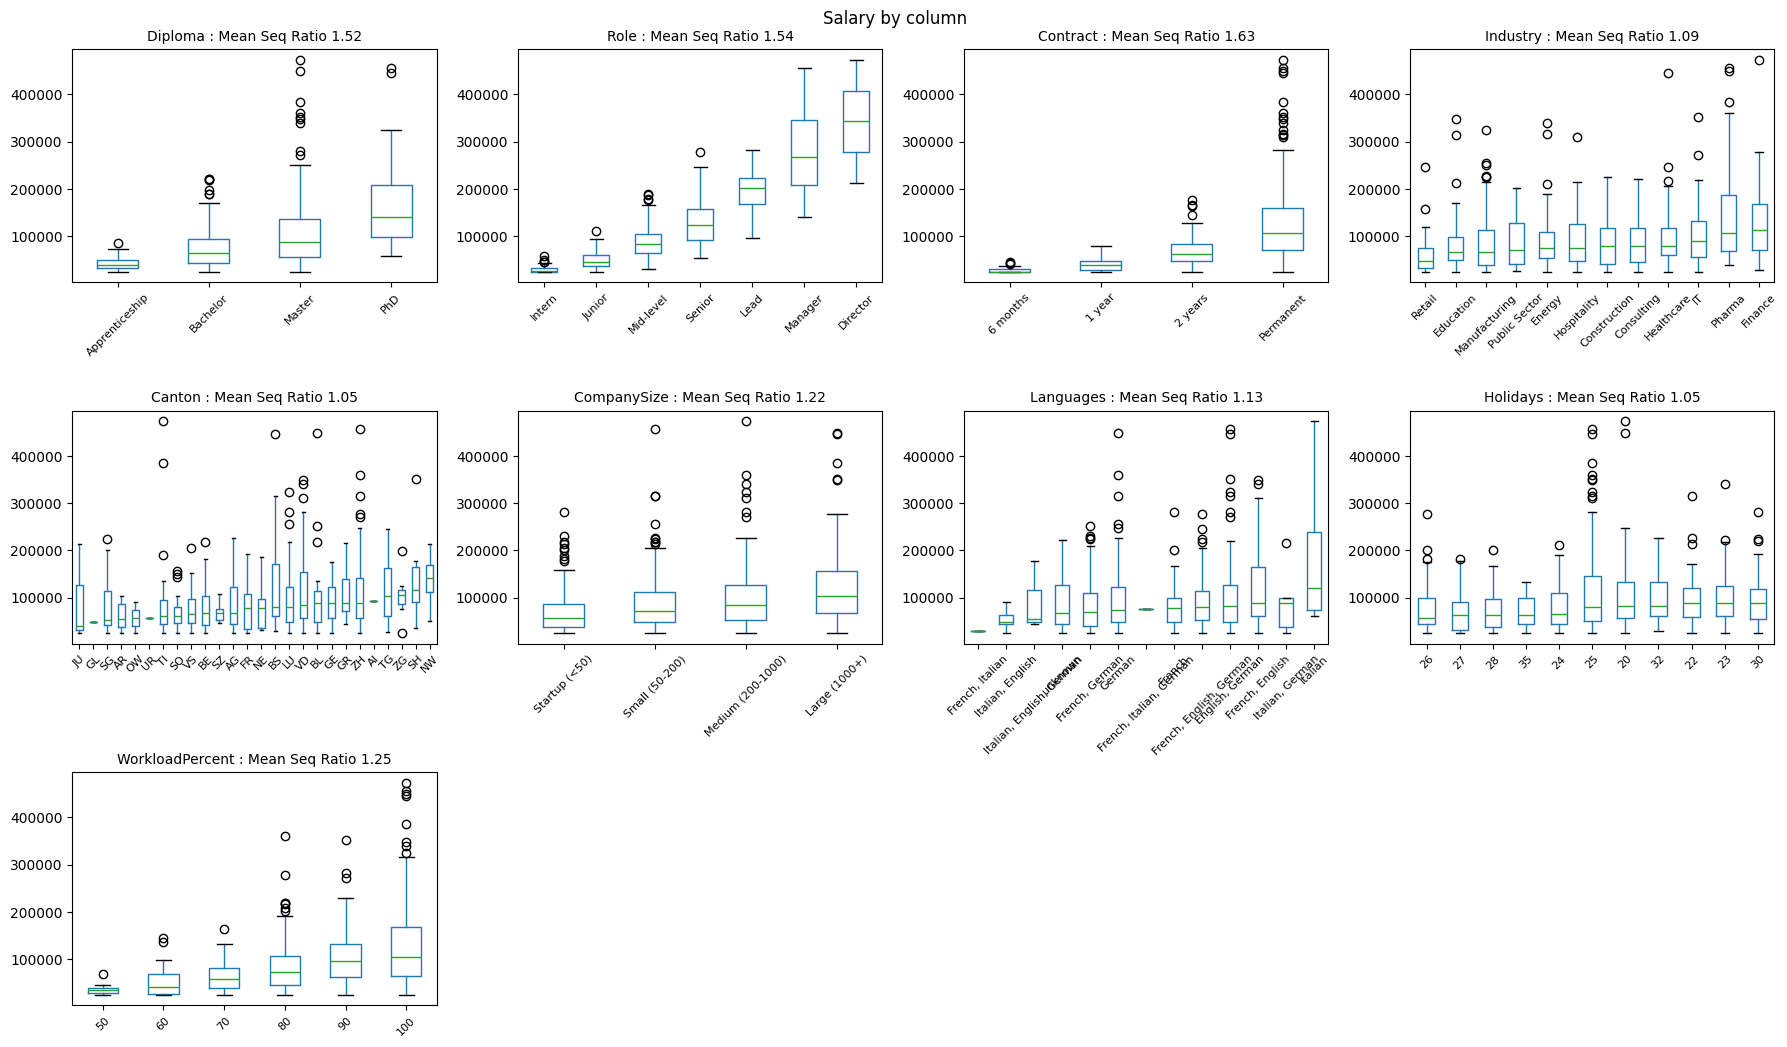

{'Diploma': np.float64(1.52), 'Role': np.float64(1.54), 'Contract': np.float64(1.63)}


In [1086]:

col_ratios = {}

cols = data.columns.drop("SalaryCHF")
fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for ax, col in zip(axes.ravel(), cols):
    sorted_medians = data.groupby(col)["SalaryCHF"].median().sort_values()
    order = sorted_medians.index

    sequential_ratio = sorted_medians / sorted_medians.shift(1)

    mean_sequential_ratio = sequential_ratio.mean()

    #print(f"Sequential ratio for {col}: {sequential_ratio}")
    #print(f"-Mean sequential ratio : {mean_sequential_ratio}-")
    
    
    tmp = data.assign(**{col: pd.Categorical(data[col], order, ordered=True)})
    tmp.boxplot(column="SalaryCHF", by=col, ax=ax, grid=False)
    ax.set_title(f"{col} : Mean Seq Ratio {mean_sequential_ratio.round(2)}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    

for ax in axes.ravel()[len(cols):]:
    ax.set_visible(False)

fig.suptitle("Salary by column")
plt.tight_layout()
plt.show()
#ax.set_title('Salary Distribution')

THRESHOLD_RATIO = 1.4

for col in cols:
    sorted_medians = data.groupby(col)["SalaryCHF"].median().sort_values()
    sequential_ratio = sorted_medians / sorted_medians.shift(1)
    mean_sequential_ratio = sequential_ratio.mean()

    if mean_sequential_ratio > THRESHOLD_RATIO:
        col_ratios[col] = mean_sequential_ratio.round(2)

print(col_ratios)



In [1087]:
data['Diploma'].value_counts()
data['Role'].value_counts()
#data['MinYearsExperience'].value_counts()

Role
Mid-level    172
Junior       134
Senior        94
Intern        46
Manager       26
Lead          26
Director       2
Name: count, dtype: int64

In [1088]:
#PUT ALL THE SALARY AT A 100% WORKLOAD
data["SalaryCHF"] = (data["SalaryCHF"] / data["WorkloadPercent"] * 100).round()

data = data.drop('WorkloadPercent', axis=1)

In [1089]:
"""

bounds = data["MinYearsExperience"].str.extract(r"(\d+)\s*to\s*(\d+)").astype(float)
data["ExpMin"] = bounds[0]
data["ExpMax"] = bounds[1]
data = data.drop(columns="MinYearsExperience")

data
"""

<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\gaeta\AppData\Local\Temp\ipykernel_7776\2378055736.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  bounds = data["MinYearsExperience"].str.extract(r"(\d+)\s*to\s*(\d+)").astype(float)


'\n\nbounds = data["MinYearsExperience"].str.extract(r"(\\d+)\\s*to\\s*(\\d+)").astype(float)\ndata["ExpMin"] = bounds[0]\ndata["ExpMax"] = bounds[1]\ndata = data.drop(columns="MinYearsExperience")\n\ndata\n'

In [1090]:
LANGUAGES = ["French", "German", "English", "Italian"]
for lang in LANGUAGES:
    data[f"Lang_{lang}"] = data["Languages"].str.contains(lang).astype(int)
data["LangCount"] = data[[f"Lang_{l}" for l in LANGUAGES]].sum(axis=1)
data = data.drop(columns="Languages")

data

,Diploma,Role,Contract,Industry,Canton,CompanySize,Holidays,SalaryCHF,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount
0,PhD,Manager,Permanent,Education,ZH,Small (50-200),25,314500.0,0,1,1,0,2
1,Bachelor,Senior,Permanent,Manufacturing,SO,Large (1000+),25,143600.0,1,1,0,0,2
2,Bachelor,Mid-level,Permanent,Manufacturing,SO,Medium (200-1000),25,84300.0,0,1,1,0,2
3,Bachelor,Junior,1 year,Healthcare,BE,Small (50-200),25,50333.0,0,1,1,0,2
4,PhD,Mid-level,Permanent,Finance,FR,Medium (200-1000),26,144667.0,1,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Master,Intern,6 months,Hospitality,SO,Startup (<50),28,41667.0,1,1,1,0,3
496,Apprenticeship,Junior,Permanent,Finance,ZH,Medium (200-1000),25,84500.0,1,1,0,0,2
497,Bachelor,Senior,Permanent,Manufacturing,TG,Large (1000+),24,152750.0,0,1,0,0,1
498,Bachelor,Mid-level,2 years,Consulting,ZH,Medium (200-1000),28,114444.0,0,1,0,0,1


In [1091]:
DIPLOMA_ORDER = ["None", "Apprenticeship", "Bachelor", "Master", "PhD"]
SIZE_ORDER = ["Startup (<50)", "Small (50-200)", "Medium (200-1000)", "Large (1000+)"]

print("Diploma :", sorted(data["Diploma"].unique()))
print("Size :", sorted(data["CompanySize"].unique()))
 
data["DiplomaLevel"] = data["Diploma"].map(
    {name: i for i, name in enumerate(DIPLOMA_ORDER)}
)
data["CompanySizeLevel"] = data["CompanySize"].map(
    {name: i for i, name in enumerate(SIZE_ORDER)}
)
data = data.drop(columns=["Diploma", "CompanySize"])
data

Diploma : ['Apprenticeship', 'Bachelor', 'Master', 'PhD']
Size : ['Large (1000+)', 'Medium (200-1000)', 'Small (50-200)', 'Startup (<50)']


,Role,Contract,Industry,Canton,Holidays,SalaryCHF,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount,DiplomaLevel,CompanySizeLevel
0,Manager,Permanent,Education,ZH,25,314500.0,0,1,1,0,2,4,1
1,Senior,Permanent,Manufacturing,SO,25,143600.0,1,1,0,0,2,2,3
2,Mid-level,Permanent,Manufacturing,SO,25,84300.0,0,1,1,0,2,2,2
3,Junior,1 year,Healthcare,BE,25,50333.0,0,1,1,0,2,2,1
4,Mid-level,Permanent,Finance,FR,26,144667.0,1,1,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Intern,6 months,Hospitality,SO,28,41667.0,1,1,1,0,3,3,0
496,Junior,Permanent,Finance,ZH,25,84500.0,1,1,0,0,2,1,2
497,Senior,Permanent,Manufacturing,TG,24,152750.0,0,1,0,0,1,2,3
498,Mid-level,2 years,Consulting,ZH,28,114444.0,0,1,0,0,1,2,2


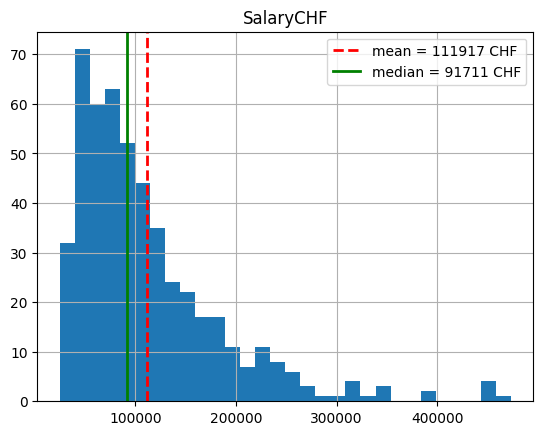

In [1092]:
histo = data['SalaryCHF'].hist(bins=30)
mean = data['SalaryCHF'].mean()
median = data['SalaryCHF'].median()
histo.axvline(
    x=mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"mean = {int(mean)} CHF"
)
histo.axvline(
    x=median,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"median = {int(median)} CHF"
)
plt.title('SalaryCHF')
plt.legend()
plt.show()

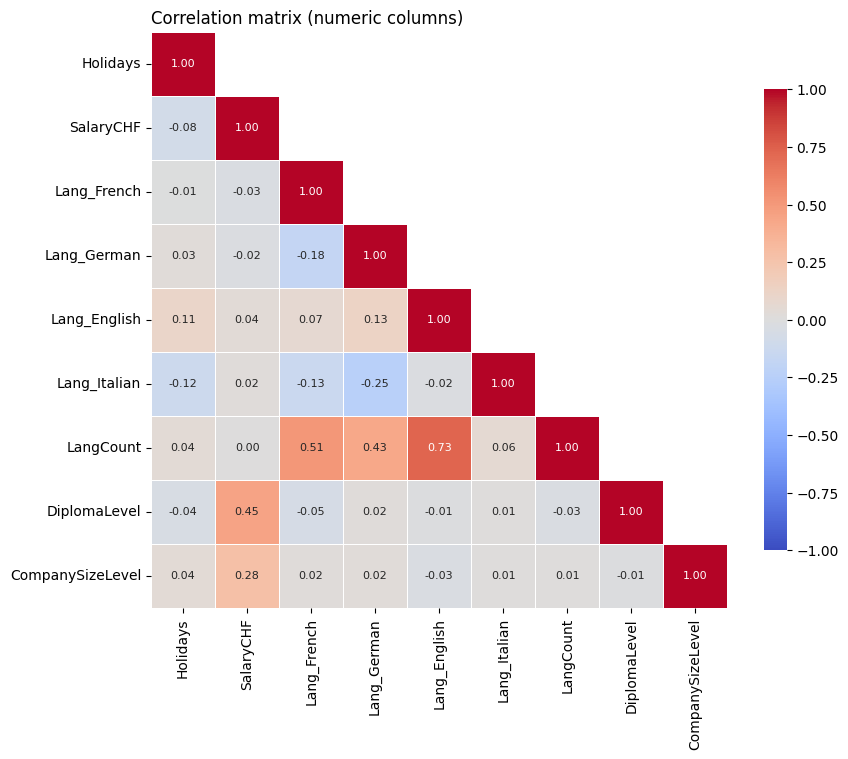

In [1093]:
corr = data.select_dtypes("number").corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            annot_kws={"size": 8}, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation matrix (numeric columns)", loc="left")
plt.tight_layout()
plt.show()


In [1094]:
counts = data["Canton"].value_counts()
rare = counts[counts < 10].index
print(f"{len(rare)} cCANTONS PUT TOGETHER, THEY ARE TOO RARE", list(rare))
data["Canton"] = data["Canton"].where(~data["Canton"].isin(rare), "Other")
data

12 cCANTONS PUT TOGETHER, THEY ARE TOO RARE ['SZ', 'NE', 'ZG', 'GR', 'SH', 'AR', 'NW', 'JU', 'OW', 'UR', 'AI', 'GL']


,Role,Contract,Industry,Canton,Holidays,SalaryCHF,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount,DiplomaLevel,CompanySizeLevel
0,Manager,Permanent,Education,ZH,25,314500.0,0,1,1,0,2,4,1
1,Senior,Permanent,Manufacturing,SO,25,143600.0,1,1,0,0,2,2,3
2,Mid-level,Permanent,Manufacturing,SO,25,84300.0,0,1,1,0,2,2,2
3,Junior,1 year,Healthcare,BE,25,50333.0,0,1,1,0,2,2,1
4,Mid-level,Permanent,Finance,FR,26,144667.0,1,1,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Intern,6 months,Hospitality,SO,28,41667.0,1,1,1,0,3,3,0
496,Junior,Permanent,Finance,ZH,25,84500.0,1,1,0,0,2,1,2
497,Senior,Permanent,Manufacturing,TG,24,152750.0,0,1,0,0,1,2,3
498,Mid-level,2 years,Consulting,ZH,28,114444.0,0,1,0,0,1,2,2


In [1095]:

from sklearn import linear_model
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LassoCV

SEED = 42

X = data.drop(columns=["SalaryCHF"])
y = data["SalaryCHF"]

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])

linear = TransformedTargetRegressor(
    regressor=LinearRegression()
)

linear_log = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,
    inverse_func=np.exp,
)

gradient_boosting = TransformedTargetRegressor(
    regressor=GradientBoostingRegressor(random_state=SEED),
    #func=np.log,
    #inverse_func=np.exp
)

lasso = TransformedTargetRegressor(
    regressor=LassoCV(max_iter=50000, random_state=SEED),
    func=np.log,
    inverse_func=np.exp,
)

model = Pipeline([
    ("prep", preprocess),
    ("reg", linear),
])

model_log = Pipeline([
    ("prep", preprocess),
    ("reg", linear_log),
])

model_gb = Pipeline([
    ("prep", preprocess),
    ("reg", gradient_boosting),
])

model_lasso = Pipeline([
    ("prep", preprocess),
    ("reg", lasso),
])

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED) #test = 20% of the data -> 100
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=SEED)#val = 25% of the remaining 80% -> 20% of the total data -> 100
#train = 300

model.fit(X_train, y_train)
y_pred = model.predict(X_val)

model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_val)

best_score = -np.inf
best_lr = None
best_depth = None
for lr in [0.05, 0.1, 0.2]:
    for d in [2, 3, 5]:
        model_gb.set_params(reg__regressor__learning_rate=lr,
                            reg__regressor__max_depth=d)
        model_gb.fit(X_train, y_train)
        score = round(model_gb.score(X_val, y_val), 4)
        if score > best_score:
            best_score = score
            best_lr = lr
            best_depth = d
        #print(lr, d, round(model_gb.score(X_val, y_val), 4))

print("best: ",best_lr, best_depth, best_score)

model_gb.set_params(reg__regressor__learning_rate=best_lr,
                    reg__regressor__max_depth=best_depth)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_val)

model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_val)

result = {}
abreviations = ["reg_wo_log", "reg_w_log", "grad_boost", "lasso"]

validation_r2_wo_log = model.score(X_val, y_val)
print("Validation R^2 w/o log:", validation_r2_wo_log)

validation_r2_log = model_log.score(X_val, y_val)
print("Validation R^2 log:", validation_r2_log)

validation_r2_gb = model_gb.score(X_val, y_val)
print("Validation R^2 gb:", validation_r2_gb)

validation_r2_lasso = model_lasso.score(X_val, y_val)
print("Validation R^2 lasso:", validation_r2_lasso)

model_lasso.fit(X_temp, y_temp)      
y_pred_test = model_lasso.predict(X_test)
print(f"TEST  R^2 = {r2_score(y_test, y_pred_test):.4f}  MAE = {mean_absolute_error(y_test, y_pred_test):.0f} CHF")


best:  0.2 3 0.913
Validation R^2 w/o log: 0.89757657467395
Validation R^2 log: 0.9878983360922945
Validation R^2 gb: 0.9129529802491154
Validation R^2 lasso: 0.9880640849911504
TEST  R^2 = 0.9928  MAE = 5354 CHF


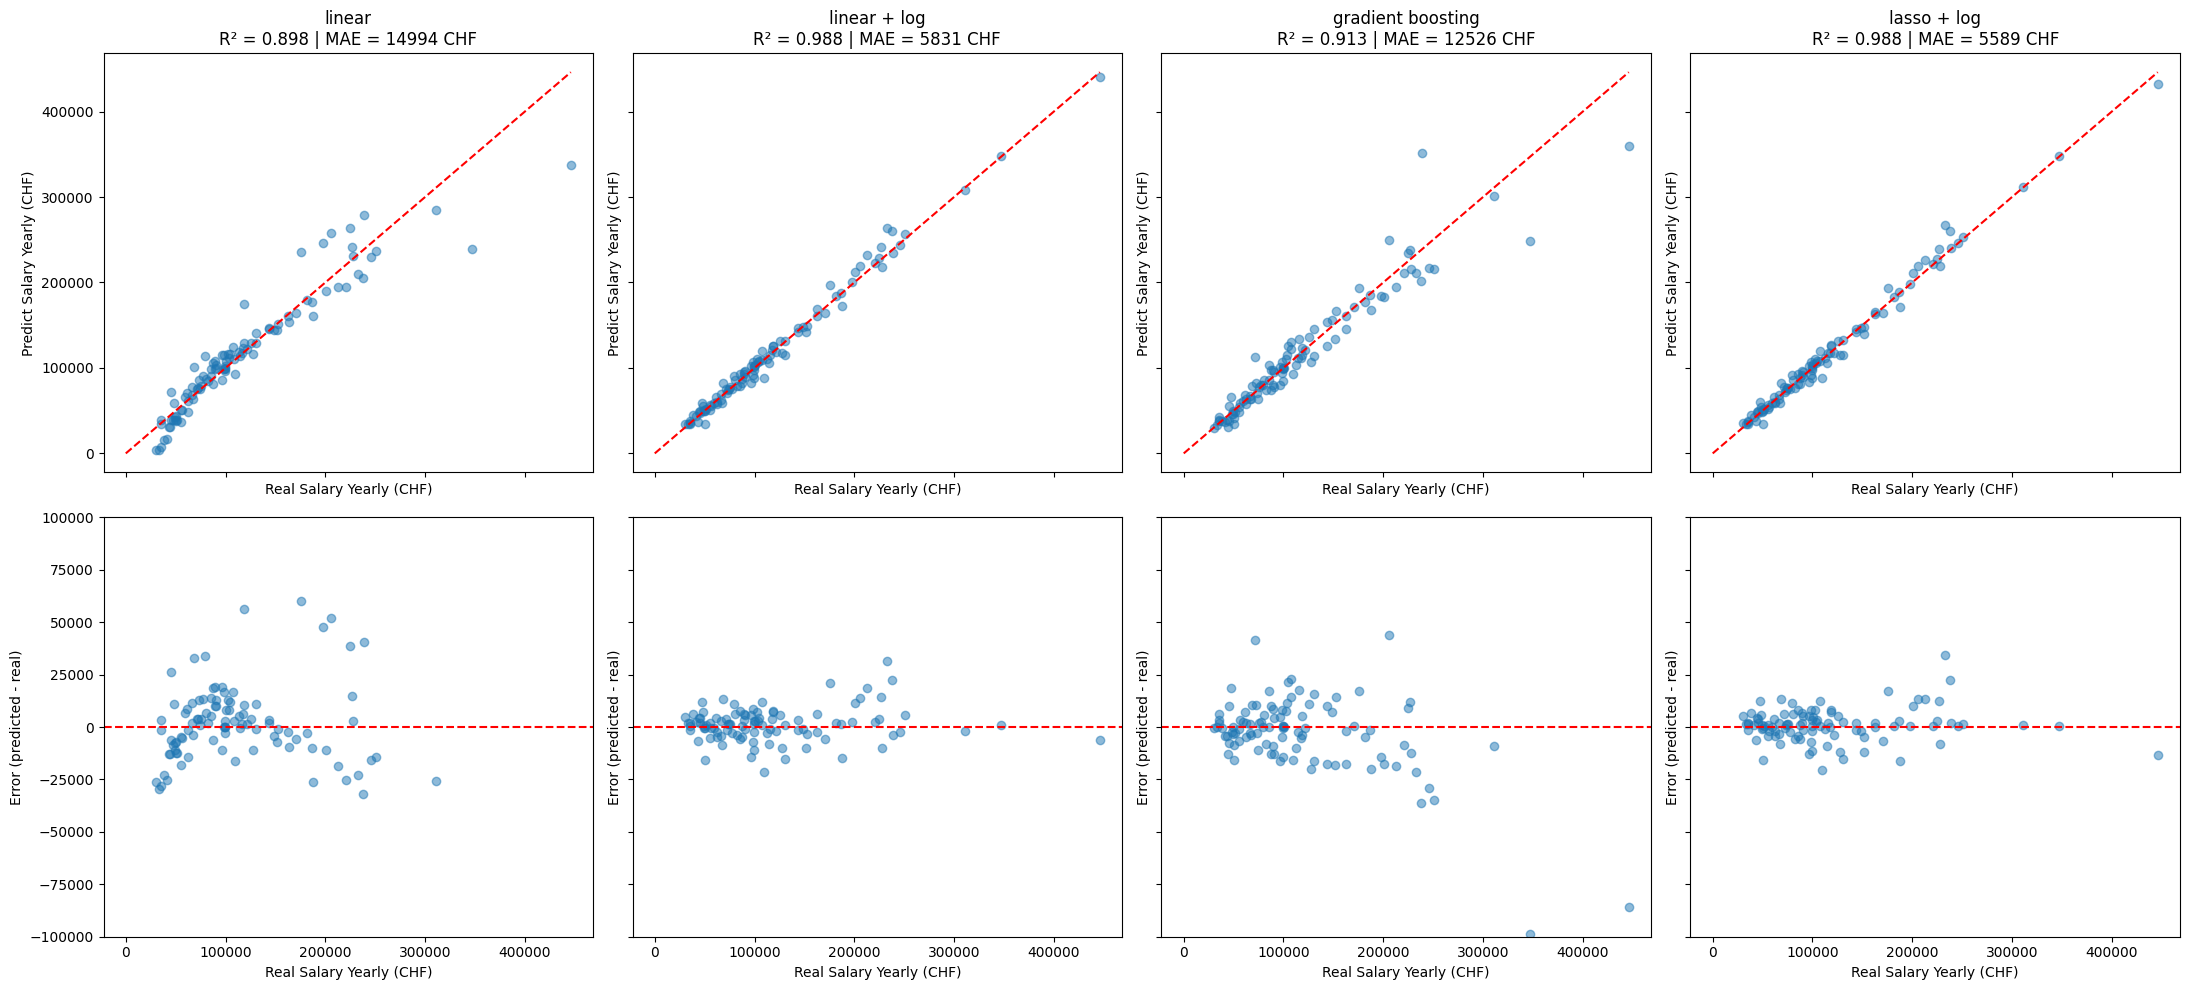

In [1096]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey="row")

preds = [(y_pred, "linear"), (y_pred_log, "linear + log"),
         (y_pred_gb, "gradient boosting"), (y_pred_lasso, "lasso + log")]

for i, (pred, nom) in enumerate(preds):
    ax = axes[0, i]
    ax.scatter(y_val, pred, alpha=0.5)
    lims = [0, max(y_val.max(), pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Real Salary Yearly (CHF)")
    ax.set_ylabel("Predict Salary Yearly (CHF)")
    ax.set_title(f"{nom}\nR² = {r2_score(y_val, pred):.3f} | MAE = {mean_absolute_error(y_val, pred):.0f} CHF")

    ax = axes[1, i]
    ax.scatter(y_val, pred - y_val, alpha=0.5)
    ax.set_ylim(-100000, 100000)
    ax.axhline(0, color="r", linestyle="--")
    ax.set_xlabel("Real Salary Yearly (CHF)")
    ax.set_ylabel("Error (predicted - real)")
plt.tight_layout()
plt.show()

In [1097]:
models = {
    "reg_wo_log": (model, y_pred),
    "reg_w_log": (model_log, y_pred_log),
    "grad_boost": (model_gb, y_pred_gb),
    "lasso": (model_lasso, y_pred_lasso),
}

result = {
    name: {
        "R2_val": r2_score(y_val, pred),
        "MAE_val": mean_absolute_error(y_val, pred),
        "RMSE_val": np.sqrt(mean_squared_error(y_val, pred)),
    }
    for name, (m, pred) in models.items()
}

pd.DataFrame(result).T.round(3)

,R2_val,MAE_val,RMSE_val
reg_wo_log,0.898,14993.529,23550.938
reg_w_log,0.988,5831.381,8095.266
grad_boost,0.913,12525.534,21711.285
lasso,0.988,5589.068,8039.637


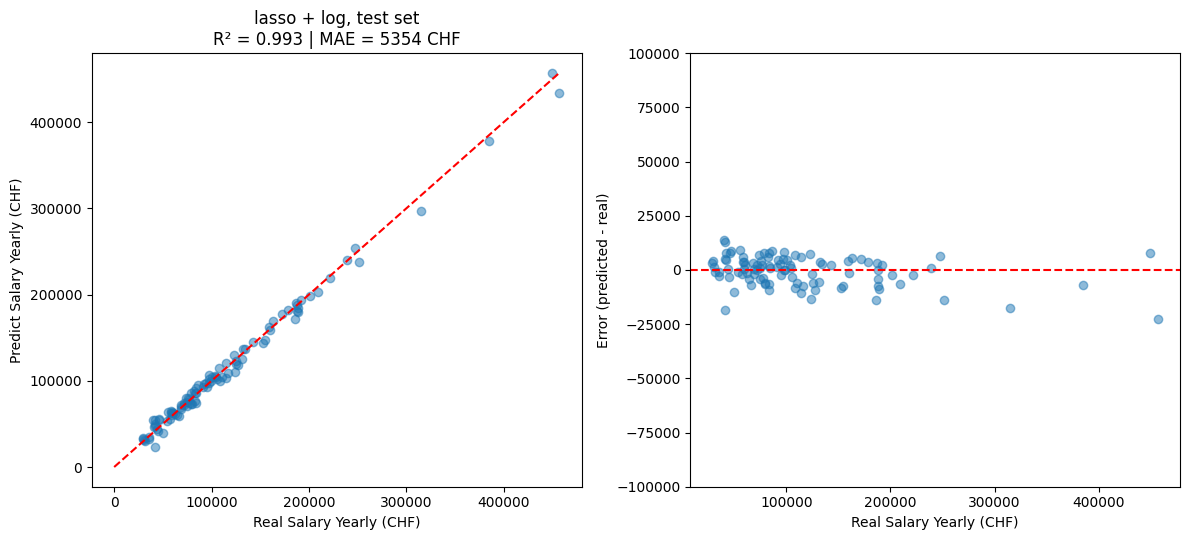

In [1098]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5)
lims = [0, max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Real Salary Yearly (CHF)")
axes[0].set_ylabel("Predict Salary Yearly (CHF)")
axes[0].set_title(f"lasso + log, test set\nR² = {r2_score(y_test, y_pred_test):.3f} | MAE = {mean_absolute_error(y_test, y_pred_test):.0f} CHF")

axes[1].scatter(y_test, y_pred_test - y_test, alpha=0.5)
axes[1].set_ylim(-100000, 100000)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Real Salary Yearly (CHF)")
axes[1].set_ylabel("Error (predicted - real)")

plt.tight_layout()
plt.show()

In [1099]:
r = model_lasso.named_steps["reg"].regressor_
name = model_lasso.named_steps["prep"].get_feature_names_out()

coef_lasso = pd.DataFrame({"feature": name, "coef": r.coef_})
coef_lasso["effet_%"] = (np.exp(coef_lasso["coef"]) - 1) * 100
deleted = coef_lasso[coef_lasso["coef"] == 0]

print(f"alpha kept : {r.alpha_:.6f}")
print(f"{len(deleted)}/{len(coef_lasso)} coefficients cancelled")
print(deleted["feature"].tolist())

coef_lasso.reindex(coef_lasso["coef"].abs().sort_values(ascending=False).index).round(2)

alpha kept : 0.000284
3/42 coefficients cancelled
['num__LangCount', 'cat__Role_Manager', 'cat__Canton_BL']


,feature,coef,effet_%
8,cat__Role_Intern,-1.70,-81.75
9,cat__Role_Junior,-1.30,-72.74
12,cat__Role_Mid-level,-0.95,-61.43
13,cat__Role_Senior,-0.61,-45.83
25,cat__Industry_Pharma,0.34,41.05
20,cat__Industry_Finance,0.33,38.83
10,cat__Role_Lead,-0.31,-26.38
23,cat__Industry_IT,0.26,30.26
17,cat__Industry_Consulting,0.22,24.90
7,num__CompanySizeLevel,0.20,21.96


In [ ]:
import json

p = model_lasso.named_steps["prep"]
r = model_lasso.named_steps["reg"].regressor_
sc = p.named_transformers_["num"]
enc = p.named_transformers_["cat"]

export = {
    "intercept": float(r.intercept_),
    "numeric": {n: {"mean": float(m), "std": float(s), "coef": float(c)}
                for n, m, s, c in zip(num_cols, sc.mean_, sc.scale_, r.coef_[:len(num_cols)])},
    "categorical": {},
}

i = len(num_cols)
for col, cats in zip(cat_cols, enc.categories_):
    export["categorical"][col] = {"__reference__": cats[0]}
    for c in cats[1:]:
        export["categorical"][col][str(c)] = float(r.coef_[i])
        i += 1

with open("salary_model.json", "w") as f:
    json.dump(export, f, indent=2, ensure_ascii=False)

print(f"{i} export coeff")

42 export coeff
